In [1]:
import torch as tc
import numpy as np
import qutip as qt
import function as my
import matplotlib.pyplot as plt
from tqdm import tqdm

class SIN(tc.nn.Module):
    def __init__(self): 
        super(SIN, self).__init__() 
    def forward(self, x):
        return tc.sin(x)

In [2]:
tfinal      = 2*np.pi
N           = 100
Nedo        = 15
Nfield      = 1

/home/gubio/anaconda3/lib/python3.13/site-packages/qutip/solver/options.py:16: FutureWarning: Dedicated options class are no longer needed, options should be passed as dict to solvers.
  warnings.warn(


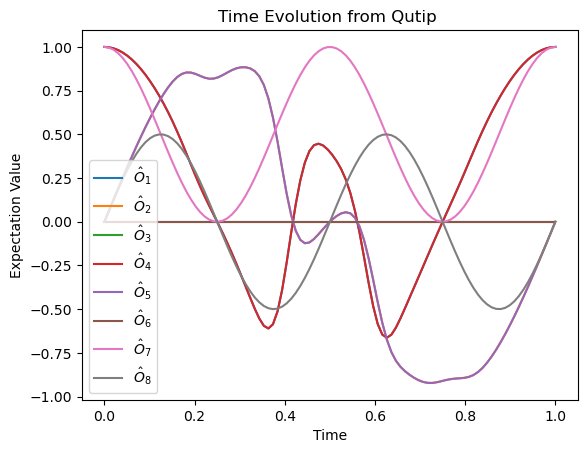

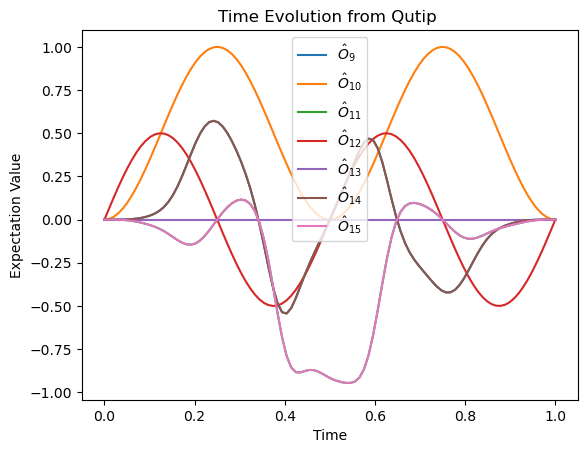

/tmp/ipykernel_3214424/863151574.py:70: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


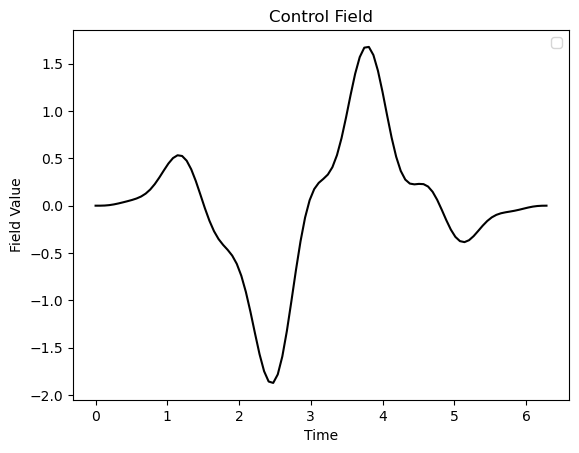

In [3]:
O_op =[ qt.tensor(qt.sigmax(), qt.qeye(2)),
        qt.tensor(qt.sigmay(), qt.qeye(2)),
        qt.tensor(qt.sigmaz(), qt.qeye(2)),
        qt.tensor(qt.qeye(2), qt.sigmax()),
        qt.tensor(qt.qeye(2), qt.sigmay()),
        qt.tensor(qt.qeye(2), qt.sigmaz()),
        qt.tensor(qt.sigmax(), qt.sigmax()),
        qt.tensor(qt.sigmax(), qt.sigmay()),
        qt.tensor(qt.sigmax(), qt.sigmaz()),
        qt.tensor(qt.sigmay(), qt.sigmay()),
        qt.tensor(qt.sigmay(), qt.sigmaz()),
        qt.tensor(qt.sigmay(), qt.sigmax()),
        qt.tensor(qt.sigmaz(), qt.sigmaz()),
        qt.tensor(qt.sigmaz(), qt.sigmax()),
        qt.tensor(qt.sigmaz(), qt.sigmay()),
        ]

def Field(t):
    return ( 1.5* np.sin(2.0 * t) - 0.3*np.cos(3* t - 0.5) + 0.4*np.sin(7.0 * t)
        )*np.sin(np.pi*t/tfinal)**2
    #return np.cos( t) 

def data_qubit(O_op,tlist,field,device="cpu"):
    # Lista de tempos para a evolução
    H0 = 0.5*qt.tensor(qt.qeye(2), qt.sigmaz()) + 0.5*qt.tensor(qt.sigmaz(), qt.qeye(2))
    H1 = qt.tensor(qt.sigmax(), qt.sigmax()) + qt.tensor(qt.sigmay(), qt.sigmay())
    H  = [H0,[H1,field(tlist)]]
    
    # Hamiltonian Lindbladian
    c_ops = []
    
    # Estado inicial (cada qubit na superposição de |0> e |1>)
    # |+> = (|0> + |1>)/sqrt(2)
    theta1  = np.pi/4
    phi1    = 0.0 #np.pi/3
    ket_plus1 = (np.cos(theta1)*qt.basis(2, 0)+np.sin(theta1)*np.exp(1j*phi1)*qt.basis(2, 1))
    psi0 = qt.tensor(ket_plus1, ket_plus1)
    
    # Solução da equação de Schrödinger
    options = qt.Options(nsteps = 100000, atol = 1e-14, rtol = 1e-14)
    result  = qt.mesolve(H, psi0, tlist, c_ops=c_ops, e_ops=O_op,options=options)

    return tc.tensor( np.array( result.expect),device = device).transpose(0, 1)

tlist = np.linspace(0.0, tfinal, N)
valor_esperado_data  = data_qubit(O_op,tlist,Field,device="cpu")

for i in range(8):
    plt.plot(tlist/tfinal,valor_esperado_data[:,i].cpu() ,label=fr"$\hat{{O}}_{{{i+1}}}$" )
    
plt.xlabel('Time')
plt.ylabel('Expectation Value')
plt.legend()
plt.title('Time Evolution from Qutip ')
plt.show()

for i in range(8,len(O_op)):
    plt.plot(tlist/tfinal,valor_esperado_data[:,i].cpu() ,label=fr"$\hat{{O}}_{{{i+1}}}$" )
    
plt.xlabel('Time')
plt.ylabel('Expectation Value')
plt.legend()
plt.title('Time Evolution from Qutip ')
plt.show()


plt.plot(tlist,Field(tlist),'k-')
plt.xlabel('Time')
plt.ylabel('Field Value')
plt.legend()
plt.title('Control Field')
plt.show()


In [4]:
neuronio = [15,15]
X_vector   = my.Rede(
    neuronio    = neuronio,
    input_      = 1,
    output_     = Nedo+Nfield,
    activation  =[SIN()]*len(neuronio))

neuronio = [2,2]
p_vector   = my.Rede(
    neuronio    = neuronio,
    input_      = 1,
    output_     = 1,
    activation  =[SIN()]*len(neuronio))

opt = tc.optim.Adam(list(X_vector.parameters()) + list(p_vector.parameters()),
        lr = 0.001,weight_decay=1e-3 )
time =  tc.linspace(
        0,
        tfinal,
        N,
        dtype   = tc.float32,
        requires_grad = True).reshape((-1, 1))

100%|██████████| 10000/10000 [00:34<00:00, 289.71it/s]


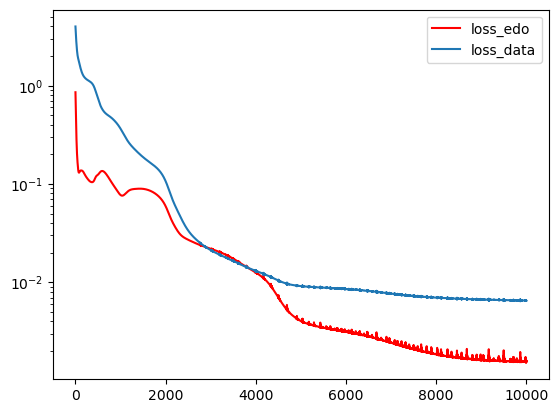

In [5]:
JIZ, JZI = (.5,.5)
epocas  = 10000

LOSS    = []
LOSS1   = []
LOSS2   = []
hisorty_of_param = []
for _ in tqdm(range(epocas)):
    ####### Forward pass #######
    y = X_vector(time)
    J = p_vector(time) # acoplamento a ser encontrado

    ######## Loss edo #######
    dX_dt = []
    for i in range(y.shape[1]-1):
        dX_dt.append(tc.autograd.grad(outputs = y[:, i],
                                    inputs = time,
                                    grad_outputs = tc.ones_like(y[:, i]),
                                    #retain_graph = True,
                                    create_graph = True)[0])
    dX_dt   = tc.cat(dX_dt, dim=1)

    IX,IY,IZ     = y[:, 0:1], y[:, 1:2], y[:, 2:3],
    XI,XX,XY,XZ = y[:, 3:4], y[:, 4:5], y[:, 5:6], y[:, 6:7]
    YI,YX,YY,YZ = y[:, 7:8], y[:, 8:9], y[:, 9:10], y[:, 10:11]
    ZI,ZX,ZY,ZZ  = y[:, 11:12], y[:, 12:13], y[:, 13:14], y[:, 14:15]
    II = tc.ones_like(IX)  # <II> = 1 sempre
    
    dIX,dIY,dIZ,dXI,dXX,dXY,dXZ = dX_dt[:, 0:1], dX_dt[:, 1:2], dX_dt[:, 2:3], dX_dt[:, 3:4], dX_dt[:, 4:5], dX_dt[:, 5:6], dX_dt[:, 6:7]
    dYI,dYX,dYY,dYZ,dZI,dZX,dZY,dZZ = dX_dt[:, 7:8], dX_dt[:, 8:9], dX_dt[:, 9:10], dX_dt[:, 10:11], dX_dt[:, 11:12], dX_dt[:, 12:13], dX_dt[:, 13:14], dX_dt[:, 14:15]
        
    LOSS_edo  = 0
    LOSS_edo += (dX_dt[:,0:1] - ( +IY*(-2.0*JIZ) +(2.0*J)*YZ))**2
    LOSS_edo += (dX_dt[:,1:2] - ( +IX*(2.0*JIZ) +(-2.0*J)*XZ))**2
    LOSS_edo += (dX_dt[:,2:3] - ( +(2.0*J)*XY +(-2.0*J)*YX))**2
    LOSS_edo += (dX_dt[:,3:4] - ( +(-2.0*JZI)*YI +(2.0*J)*ZY))**2
    LOSS_edo += (dX_dt[:,4:5] - ( +(-2.0*JIZ)*XY +(-2.0*JZI)*YX))**2
    LOSS_edo += (dX_dt[:,5:6] - ( +IZ*(-2.0*J) +(2.0*JIZ)*XX +(-2.0*JZI)*YY +(2.0*J)*ZI))**2
    LOSS_edo += (dX_dt[:,6:7] - ( +IY*(2.0*J) +(-2.0*JZI)*YZ))**2
    LOSS_edo += (dX_dt[:,7:8] - ( +(2.0*JZI)*XI +(-2.0*J)*ZX))**2
    LOSS_edo += (dX_dt[:,8:9] - ( +IZ*(2.0*J) +(2.0*JZI)*XX +(-2.0*JIZ)*YY +(-2.0*J)*ZI))**2
    LOSS_edo += (dX_dt[:,9:10] - ( +(2.0*JZI)*XY +(2.0*JIZ)*YX))**2
    LOSS_edo += (dX_dt[:,10:11] - ( +IX*(-2.0*J) +(2.0*JZI)*XZ))**2
    LOSS_edo += (dX_dt[:,11:12] - ( +(-2.0*J)*XY +(2.0*J)*YX))**2
    LOSS_edo += (dX_dt[:,12:13] - ( +(2.0*J)*YI +(-2.0*JIZ)*ZY))**2
    LOSS_edo += (dX_dt[:,13:14] - ( +(-2.0*J)*XI +(2.0*JIZ)*ZX))**2
        
    LOSS_edo = LOSS_edo.mean()

    ####### loss data(expected values) #######
    LOSS_data = 0
    LOSS_data +=(IX - valor_esperado_data[:,3:4])**2
    LOSS_data +=(IY - valor_esperado_data[:,4:5])**2
    LOSS_data +=(IZ - valor_esperado_data[:,5:6])**2
    LOSS_data +=(XI - valor_esperado_data[:,0:1])**2
    LOSS_data +=(XX - valor_esperado_data[:,6:7])**2
    LOSS_data +=(XY - valor_esperado_data[:,7:8])**2
    LOSS_data +=(XZ - valor_esperado_data[:,8:9])**2
    LOSS_data +=(YI - valor_esperado_data[:,1:2])**2
    LOSS_data +=(YX - valor_esperado_data[:,11:12])**2
    LOSS_data +=(YY - valor_esperado_data[:,9:10])**2
    LOSS_data +=(YZ - valor_esperado_data[:,10:11])**2
    LOSS_data +=(ZI - valor_esperado_data[:,2:3])**2
    LOSS_data +=(ZX - valor_esperado_data[:,13:14])**2
    LOSS_data +=(ZY - valor_esperado_data[:,14:15])**2
    LOSS_data +=(ZZ - valor_esperado_data[:,12:13])**2
    LOSS_data = LOSS_data.mean()
    
    ####### Loss total #######
    loss_i = LOSS_edo + LOSS_data #+ (J[0,0] - Field(0.0))**2 + (J[-1,0] - Field(tfinal))**2

    ####### Backpropagation #######
    opt.zero_grad()
    loss_i.backward()
    opt.step()
    LOSS1.append(LOSS_edo.cpu().detach().numpy())
    LOSS2.append(LOSS_data.cpu().detach().numpy())
    LOSS.append(loss_i.cpu().detach().numpy())

#plt.plot(LOSS,"k.",label="loss_total")
plt.plot(LOSS1,'r-',label="loss_edo")
plt.plot(LOSS2,label="loss_data")
plt.yscale("log")
plt.legend()
plt.show()

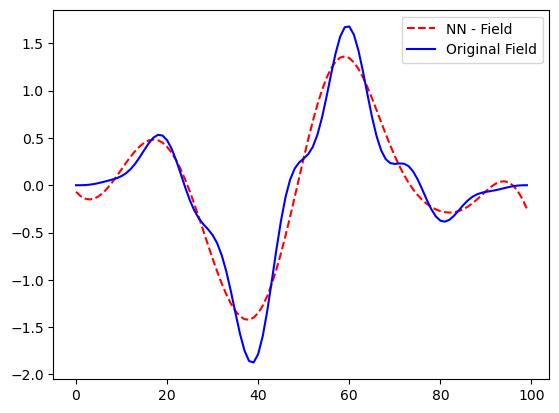

In [6]:
t_points =  np.linspace(0,tfinal, N)
X_vector.eval()
X_  = p_vector(time).detach().numpy()

field_original=Field(t_points)
plt.plot(X_,"r--",label="NN - Field")
plt.plot(field_original,"b-",label="Original Field")
plt.legend()
plt.show()

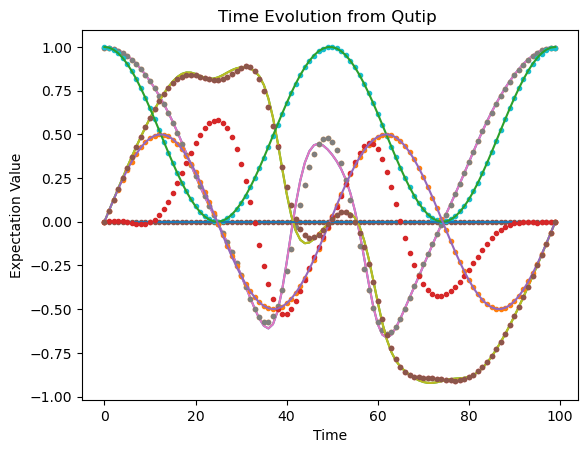

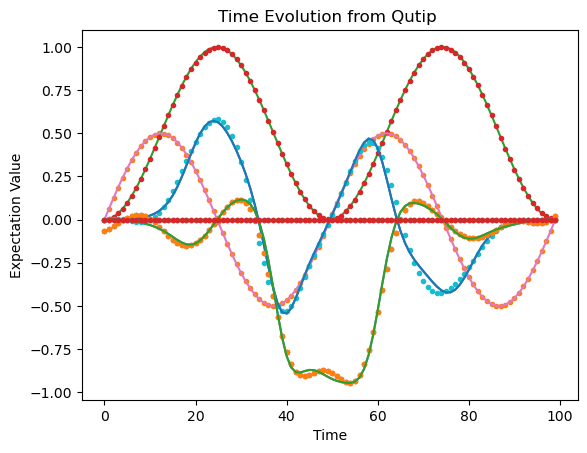

In [7]:
t_points =  np.linspace(0,tfinal, N)
X_vector.eval()
X_  = X_vector(time).detach().numpy()


for i in range(8):
    plt.plot(valor_esperado_data[:,i].cpu() )
    plt.plot(X_[:,i],"." )
    
plt.xlabel('Time')
plt.ylabel('Expectation Value')
plt.title('Time Evolution from Qutip ')
plt.show()

for i in range(8,len(O_op)):
    plt.plot(valor_esperado_data[:,i].cpu() )
    plt.plot(X_[:,i],"." )
    
plt.xlabel('Time')
plt.ylabel('Expectation Value')
plt.title('Time Evolution from Qutip ')
plt.show()

